In [2]:
#Ridge regularisation 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes

data=load_diabetes()

print(data.DESCR) #this gives descrption of data

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
X=data.data #extracts input in data
y=data.target #extracts output in data from the sklearn dataset object!

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

from sklearn.linear_model import LinearRegression
L=LinearRegression()

L.fit(X_train,y_train)
y_pred=L.predict(X_test)

In [4]:
y_pred=L.predict(X_test)
from sklearn.metrics import r2_score,mean_squared_error

print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.5188113124539249
RMSE 48.72713760953253


In [5]:
from sklearn.linear_model import Ridge
R=Ridge(alpha=0.0001) #this is lambda
R.fit(X_train,y_train)

,alpha,0.0001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [6]:
y_pred1=R.predict(X_test)
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score 0.518973263588495
RMSE 48.718937001819555


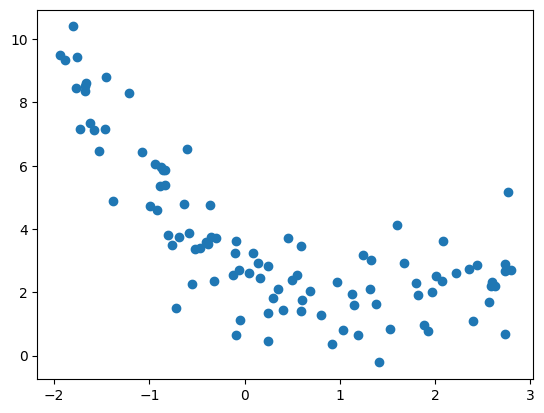

In [11]:
#Generating Synthetic Data
m = 100 # m stands for number of data points to generate , it creates 100 data points,Shape: (100, 1) -> 100 rows, 1 column
x1 = 5 * np.random.rand(m, 1) - 2  #np.random.rand(m, 1) # Creates 100 random numbers (because m=100) between 0 and 1.
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1) #Perfect polynomial relationship 

#5 * np.random.rand(m, 1)
# Scales to 0 to 5 

#5 * np.random.rand(m, 1) - 2
#this code minimises that scaling from -2 to 3. 

#x2 = 0.7 * x1**2 - 2 * x1 + 3 + np.random.randn(m, 1)

#0.7 * x1**2 - 2 * x1 + 3
# Perfect polynomial relationship

#np.random.randn(m, 1)
# Adds random noise (100 random values from normal distribution)

#x2 = 0.7 * x1**2 - 2 * x1 + 3 + noise
# OUTPUT with noise

plt.scatter(x1, x2)
plt.show()

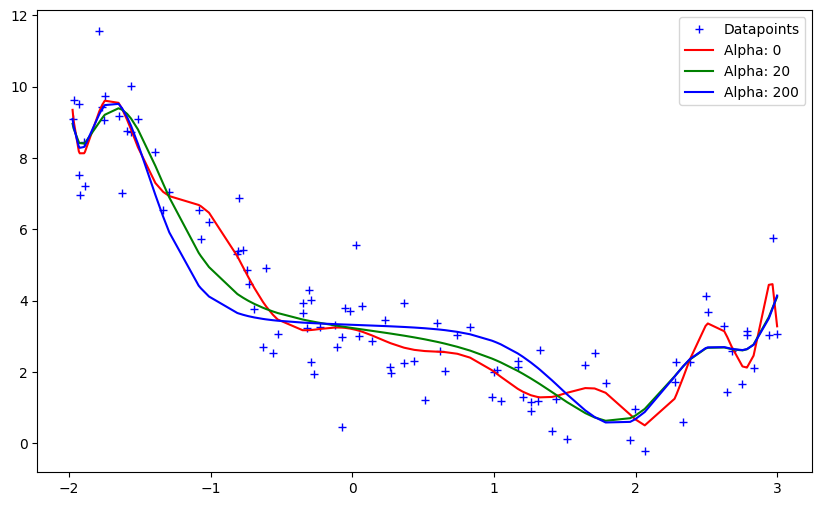

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha): # alpha is lambda
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha)) # #Ridge(alpha=alpha)-> Applies Ridge regression with given α ,and Controls overfitting!


    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()